# ORC1 Fiber Assay Analysis

**Purpose:** Compare replication speed and inter-origin distance between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-07-14

## Workflow
1. Load data
2. Clean data
3. Calculate fiber speed
4. Statistical analysis
5. Plot figures
6. Save results

# 1. Libraries import

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# 2. Parameters

In [2]:
INPUT_DIR = "/mnt/c/users/helen/Desktop/FIBERS"
OUTPUT_DIR = "/mnt/c/users/helen/Desktop/FIBERS"

conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# 3. Data loading

In [3]:
dfs = []
all_dirs = []

for root, dirs, files in os.walk(INPUT_DIR):
    all_dirs.append(dirs)
    
    for filename in files:
        if filename.lower().endswith(".csv"):

            path = os.path.join(root, filename)
            df = pd.read_csv(path)
            
            # If everything ended up in one column, try semicolon
            if df.shape[1] == 1:
                df = pd.read_csv(path, sep=";")

            # Optional metadata
            df["File"] = os.path.splitext(filename)[0].replace(" ", "_")
            df["Path"] = path

            dfs.append(df) 

# Combine all tables
data = pd.concat(dfs, ignore_index=True)

# Create ROI column
data['ROI'] = data['Label'].apply(lambda x: x.split(":")[1])

# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = None

# Delete first 3 columns
data.drop(data.columns[[0, 1, 2]], axis=1, inplace=True)

# Reorder columns
data = data[
    [
        "Sample_name",
        "File",
        "Measurement_type",
        "Length",
        "ROI",
        "Path"
    ]
]

print(f"Total number of files for analysis is: {data.shape[0]}")

Total number of files for analysis is: 1209


In [4]:
# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "1h15min" in x else x
)

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "30min" in x else x
)

mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siORC1_HaloEmpty", na=False))
)
data.loc[mask, "Sample_name"] = "siORC1"

# Update only rows where Sample_name == "HaloEmpty" and File contains "siSCR_HaloEmpty"
mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siSCR_HaloEmpty", na=False))
)

data.loc[mask, "Sample_name"] = "siSCR"

# Info about samples
sample_names = set(data["Sample_name"])
print(f"The amount of samples is: {len(sample_names)}.")
print(f"There are: {sample_names}")

The amount of samples is: 8.
There are: {'MGS3', 'MGS4', 'WT', 'MGS1', 'siSCR', 'MGS5', 'siORC1', 'MGS2'}


In [5]:
# Split data into 2 dataframes
speed = data[data['Measurement_type']=='Fiber_length']
iod = data[data['Measurement_type']=='Interorigin_distance']

## Check data. Check the number of measurements

In [6]:
speed.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
0,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,39.080,0184-0277,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
1,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,62.853,0207-0330,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
3,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,55.027,0944-0253,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
4,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,68.244,0968-0321,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
5,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,100.000,0581-0161,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


In [7]:
iod.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
2,MGS1,siORC1_MGS1-02_Interorigin_distance,Interorigin_distance,97.944,0252-0320,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
19,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,125.399,0550-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
20,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,171.724,0477-0521,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
21,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,97.546,0646-0786,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
26,MGS1,siORC1_MGS1-06_Interorigin_distance,Interorigin_distance,168.964,0345-0901,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


## Check the number of measurements for each sample

### Replication speed
Divide this number by 2 because these are green and red tracks separately.

In [8]:
speed.groupby('Sample_name')['File'].count()

Sample_name
MGS1       76
MGS2      120
MGS3      128
MGS4      106
MGS5       94
WT        148
siORC1    112
siSCR     118
Name: File, dtype: int64

In [9]:
# OPTIONAL
# Check analized files
#sample_name = "MGS5"
#speed[speed["Sample_name"] == sample_name]['File'].value_counts()

### IOD

In [10]:
iod.groupby('Sample_name')['File'].count()

Sample_name
MGS1      28
MGS2      48
MGS3      48
MGS4      23
MGS5      30
WT        50
siORC1    25
siSCR     55
Name: File, dtype: int64

In [11]:
# OPTIONAL
# Check analized files
#sample_name = "siORC1"
#iod[iod["Sample_name"] == sample_name]['File'].value_counts()

# 3. Process replication speed data

In [12]:
# Checking speed file
counts = speed.groupby("File").size()
odd_files = counts[counts % 2 != 0].index.tolist()

if len(odd_files) == 0:
    print("All files contain an even number of fibers.")
else:
    print("The following files contain an odd number of fibers will be removed:")
    print(*odd_files, sep="\n")
    
    # Removing odd files from speed dataframe
    speed = speed[~speed["File"].isin(odd_files)].copy()

All files contain an even number of fibers.


In [13]:
# Add extra inedex to group pairs of files
speed["Index"] = speed.groupby("File").cumcount() // 2

# Calculate sum of fiber length in pairs
speed_processed = speed.groupby(["File", "Index"], as_index=False).agg(
        Total_Length=("Length", "sum"),
        ROI=("ROI", list),
        Path=("Path", "first"),
        Sample_name=("Sample_name", "first")
        )

# Convert speed to kb/min
speed_processed['Speed_kb_min'] = speed_processed['Total_Length'].apply(lambda x: x * conversion_factor / time)

# Delete extra columns
replication_speed = speed_processed[['Sample_name', 'File', 'Speed_kb_min', 'ROI', 'Path']]

In [14]:
replication_speed

,Sample_name,File,Speed_kb_min,ROI,Path
0,WT,HCl_1h15min_15o-02_Fiber_length,7.268058,"[0172-0998, 0159-1032]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1,WT,HCl_1h15min_15o-06_Fiber_length,12.962302,"[0660-0135, 0624-0181]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
2,WT,HCl_1h15min_15o-06_Fiber_length,9.868806,"[0627-0140, 0600-0174]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
3,WT,HCl_1h15min_15o-06_Fiber_length,12.087918,"[0513-0309, 0472-0351]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
4,WT,HCl_1h15min_15o-07_Fiber_length,8.567072,"[0490-0561, 0450-0575]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
...,...,...,...,...,...
446,siSCR,siSCR_HaloEmpty-27_Fiber_length,12.910762,"[0509-0834, 0529-0891]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...
447,siSCR,siSCR_HaloEmpty-27_Fiber_length,14.660695,"[0500-1221, 0490-1159]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...
448,siSCR,siSCR_HaloEmpty-27_Fiber_length,7.513978,"[0605-1169, 0615-1202]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...
449,siSCR,siSCR_HaloEmpty-27_Fiber_length,13.485482,"[0616-0565, 0633-0620]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...


# 4. Process IOD data

In [15]:
iod['IOD_kb'] = iod['Length'].apply(lambda x: x * conversion_factor)
iod_kb = iod[["Sample_name", "File", 'IOD_kb', 'ROI', 'Path']]

iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
2,MGS1,siORC1_MGS1-02_Interorigin_distance,253.67496,0252-0320,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
19,MGS1,siORC1_MGS1-04_Interorigin_distance,324.78341,0550-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
20,MGS1,siORC1_MGS1-04_Interorigin_distance,444.76516,0477-0521,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
21,MGS1,siORC1_MGS1-04_Interorigin_distance,252.64414,0646-0786,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
26,MGS1,siORC1_MGS1-06_Interorigin_distance,437.61676,0345-0901,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


# 5. Basic statistics

## 5.1 Replication speed

In [16]:
stats_speed = (
    replication_speed.groupby("Sample_name")["Speed_kb_min"]
    .agg(
        Count="count",
        Mean="mean",
        SD="std",
    )
)

stats_speed

,Count,Mean,SD
Sample_name,,,
MGS1,38,14.331530,4.351872
MGS2,60,13.001541,3.473763
MGS3,64,13.924694,3.671007
MGS4,53,14.370053,3.719987
MGS5,47,13.441058,3.978342
WT,74,11.938206,3.446468
siORC1,56,13.100377,3.594779
siSCR,59,11.347631,3.265924


## 5.2 IOD

In [17]:
stats_iod = (
    iod_kb.groupby("Sample_name")["IOD_kb"]
    .agg(
        Count="count",
        Mean="mean",
        SD="std",
    )
)

stats_iod

,Count,Mean,SD
Sample_name,,,
MGS1,28,416.126697,100.122842
MGS2,48,379.444605,118.638065
MGS3,48,433.288384,128.943988
MGS4,23,414.329394,120.159999
MGS5,30,410.181149,143.419707
WT,50,342.657570,137.682836
siORC1,25,504.970332,204.213773
siSCR,55,323.844935,107.834065


# 6. Processing outliers in data

## 6.1 Replication speed

In [18]:
Q1 = replication_speed['Speed_kb_min'].quantile(0.25)
Q3 = replication_speed['Speed_kb_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_speed = replication_speed[(replication_speed['Speed_kb_min'] < lower) | (replication_speed['Speed_kb_min'] > upper)]

outliers_speed

,Sample_name,File,Speed_kb_min,ROI,Path
110,MGS1,siORC1_MGS1-03_Fiber_length,24.318417,"[0581-0161, 0525-0083]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
131,MGS1,siORC1_MGS1-16_Fiber_length,23.946881,"[0515-0267, 0467-0357]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
263,MGS3,siORC1_MGS3-34_Fiber_length,24.378116,"[0700-0585, 0721-0484]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
270,MGS4,siORC1_MGS4-04_Fiber_length,24.698369,"[0384-0974, 0367-1077]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
438,siSCR,siSCR_HaloEmpty-23_Fiber_length,23.696299,"[0602-0726, 0560-0639]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...


## 6.2 IOD

In [19]:
Q1 = iod_kb['IOD_kb'].quantile(0.25)
Q3 = iod_kb['IOD_kb'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iod = iod_kb[(iod_kb['IOD_kb'] < lower) | (iod_kb['IOD_kb'] > upper)]

outliers_iod

,Sample_name,File,IOD_kb,ROI,Path
772,siORC1,siORC1_HaloEmpty-03_Interorigin_distance,906.25654,0414-0814,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...
847,siORC1,siORC1_HaloEmpty-15_Interorigin_distance,783.43097,0612-0873,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...
861,siORC1,siORC1_HaloEmpty-16_Interorigin_distance,1066.03623,0316-0867,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...


# Graphs

## Replication speed graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/FIBERS


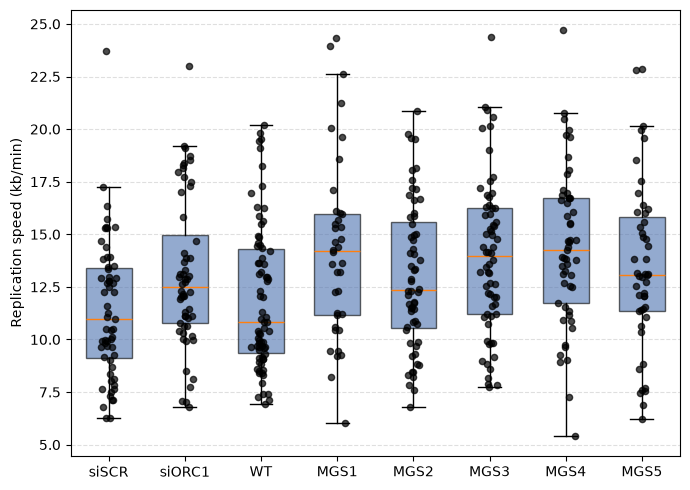

In [20]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = replication_speed
var = "Speed_kb_min"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("Replication speed (kb/min)")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {OUTPUT_DIR}")

plt.show()

## IOD graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/FIBERS


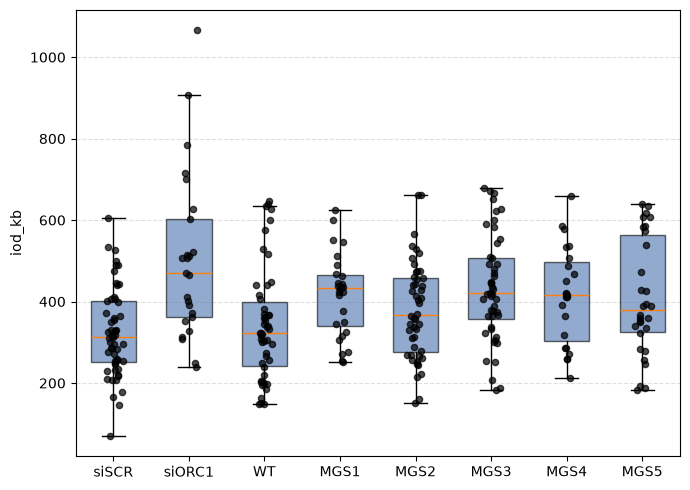

In [21]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = iod_kb
var = "IOD_kb"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("iod_kb")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/iod_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {OUTPUT_DIR}")

plt.show()

# Statistical analysis

## U-test

### Replication speed

In [27]:
# Data
data_plot = replication_speed
var = "Speed_kb_min"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = mannwhitneyu(
        wt,
        mutant
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_u_replication_speed = pd.DataFrame(results)

print(stats_u_replication_speed)

     Comparison  WT_n  Sample_n       U   p-value
0   WT vs siSCR    74        59  2364.0  0.413658
1  WT vs siORC1    74        56  1638.0  0.041536
2    WT vs MGS1    74        38   918.0  0.002737
3    WT vs MGS2    74        60  1801.0  0.061134
4    WT vs MGS3    74        64  1607.0  0.001166
5    WT vs MGS4    74        53  1187.0  0.000156
6    WT vs MGS5    74        47  1321.0  0.026402


### IOD

In [28]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = mannwhitneyu(
        wt,
        mutant
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_u_iod = pd.DataFrame(results)

print(stats_u_iod)

     Comparison  WT_n  Sample_n       U   p-value
0   WT vs siSCR    50        55  1439.0  0.683698
1  WT vs siORC1    50        25   306.0  0.000344
2    WT vs MGS1    50        28   434.0  0.005683
3    WT vs MGS2    50        48   945.0  0.070505
4    WT vs MGS3    50        48   711.0  0.000517
5    WT vs MGS4    50        23   377.0  0.019013
6    WT vs MGS5    50        30   544.0  0.041124


## *Optional: T-Test*

In [24]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = ttest_ind(
        wt,
        mutant,
        equal_var=False,   # Welch's t-test (recommended)
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_t_df = pd.DataFrame(results)

print(stats_t_df)

     Comparison  WT_n  Sample_n         U   p-value
0   WT vs siSCR    50        55  0.774141  0.440817
1  WT vs siORC1    50        25 -3.587286  0.001004
2    WT vs MGS1    50        28 -2.705991  0.008528
3    WT vs MGS2    50        48 -1.418710  0.159259
4    WT vs MGS3    50        48 -3.364743  0.001103
5    WT vs MGS4    50        23 -2.258695  0.028422
6    WT vs MGS5    50        30 -2.069318  0.042888


# Tables export

In [29]:
# Tables with processed results
replication_speed.to_excel(f"{OUTPUT_DIR}/replication_speed.xlsx", index=False)
iod_kb.to_excel(f"{OUTPUT_DIR}/iod_kb.xlsx", index=False)

# Tables with statistic
stats_u_replication_speed.to_excel(f"{OUTPUT_DIR}/stats_u_replication_speed.xlsx", index=False)
stats_u_iod.to_excel(f"{OUTPUT_DIR}/stats_u_iod.xlsx", index=False)

# Graphs with statistics

In [37]:
# -------------------------------------------------------
# Convert p-values to significance stars
# -------------------------------------------------------

def p_to_stars(p_value):
    if pd.isna(p_value):
        return ""

    if p_value < 0.0001:
        return "****"
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


# -------------------------------------------------------
# Function to draw one significance bracket
# -------------------------------------------------------

def add_bracket(ax, x1, x2, y, height, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + height, y + height, y],
        color="black",
        linewidth=1.2,
        clip_on=False,
    )

    ax.text(
        (x1 + x2) / 2,
        y + height,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
    )


In [51]:
# -------------------------------------------------------
# Prepare statistics DataFrame
# -------------------------------------------------------

stats_plot = stats_u_iod.copy()

# Split "WT vs MGS1" into two separate columns
stats_plot[["Group1", "Group2"]] = (
    stats_plot["Comparison"]
    .str.split(r"\s+vs\s+", expand=True)
)

# Rename p-value column for easier use
stats_plot = stats_plot.rename(columns={"p-value": "p_value"})

# Keep only comparisons whose groups are present in the plot
stats_plot = stats_plot[
    stats_plot["Group1"].isin(sample_order)
    & stats_plot["Group2"].isin(sample_order)
].copy()

In [ ]:
# -------------------------------------------------------
# Variables
# -------------------------------------------------------
data_plot = iod_kb
var = "IOD_kb"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

# -------------------------------------------------------
# Prepare groups
# -------------------------------------------------------
for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

# -------------------------------------------------------
# Create figure
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
    
# -------------------------------------------------------
# Draw boxplot
# -------------------------------------------------------

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
    medianprops={
        "color": "black",
        "linewidth": 1.5,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.2,
    },
    capprops={
        "color": "black",
        "linewidth": 1.2,
    },
)

for box in bp["boxes"]:
    box.set(
        facecolor="#4C72B0",
        alpha=0.6,
        edgecolor="black",
        linewidth=1.2,
    )

# -------------------------------------------------------
# Add jittered individual values
# -------------------------------------------------------
rng = np.random.default_rng(seed=42)

for position, values in enumerate(groups, start=1):
    x_jitter = rng.normal(
        loc=position,
        scale=0.05,
        size=len(values),
    )

    ax.scatter(
        x_jitter,
        values,
        s=20,
        color="black",
        alpha=0.7,
        zorder=3,
    )

# -------------------------------------------------------
# Add significance brackets
# -------------------------------------------------------
sample_positions = {
    sample: position
    for position, sample in enumerate(sample_order, start=1)
}

data_min = data_plot[var].min()
data_max = data_plot[var].max()
data_range = data_max - data_min

if data_range == 0:
    data_range = 1

bracket_height = data_range * 0.025
bracket_step = data_range * 0.10
current_y = data_max + data_range * 0.08

# Sort comparisons by distance between groups.
# Shorter brackets are drawn first.
stats_plot["span"] = stats_plot.apply(
    lambda row: abs(
        sample_positions[row["Group2"]]
        - sample_positions[row["Group1"]]
    ),
    axis=1,
)

stats_plot = stats_plot.sort_values("span")


for _, row in stats_plot.iterrows():
    group1 = row["Group1"]
    group2 = row["Group2"]
    p_value = row["p_value"]

    x1 = sample_positions[group1]
    x2 = sample_positions[group2]

    add_bracket(
        ax=ax,
        x1=x1,
        x2=x2,
        y=current_y,
        height=bracket_height,
        text=p_to_stars(p_value),
    )

    current_y += bracket_step

# -------------------------------------------------------
# Format axes
# -------------------------------------------------------
ax.set_ylabel("Inter-origin distance (kb)", fontsize=12)
ax.set_xlabel("")

plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/iod_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {OUTPUT_DIR}")

plt.show()

SyntaxError: invalid syntax (3168334345.py, line 136)

In [47]:
stats_df 

,Comparison,WT_n,Sample_n,U,p-value
0,WT vs siSCR,50,55,1439.0,0.683698
1,WT vs siORC1,50,25,306.0,0.000344
2,WT vs MGS1,50,28,434.0,0.005683
3,WT vs MGS2,50,48,945.0,0.070505
4,WT vs MGS3,50,48,711.0,0.000517
5,WT vs MGS4,50,23,377.0,0.019013
6,WT vs MGS5,50,30,544.0,0.041124


In [48]:
# -------------------------------------------------------
# Prepare statistics DataFrame
# -------------------------------------------------------

stats_plot = stats_df.copy()

# Split "WT vs MGS1" into two separate columns
stats_plot[["Group1", "Group2"]] = (
    stats_plot["Comparison"]
    .str.split(r"\s+vs\s+", expand=True)
)

# Rename p-value column for easier use
stats_plot = stats_plot.rename(columns={"p-value": "p_value"})

# Keep only comparisons whose groups are present in the plot
stats_plot = stats_plot[
    stats_plot["Group1"].isin(sample_order)
    & stats_plot["Group2"].isin(sample_order)
].copy()

In [49]:
stats_plot

,Comparison,WT_n,Sample_n,U,p_value,Group1,Group2
0,WT vs siSCR,50,55,1439.0,0.683698,WT,siSCR
1,WT vs siORC1,50,25,306.0,0.000344,WT,siORC1
2,WT vs MGS1,50,28,434.0,0.005683,WT,MGS1
3,WT vs MGS2,50,48,945.0,0.070505,WT,MGS2
4,WT vs MGS3,50,48,711.0,0.000517,WT,MGS3
5,WT vs MGS4,50,23,377.0,0.019013,WT,MGS4
6,WT vs MGS5,50,30,544.0,0.041124,WT,MGS5
